In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement des données
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

# Premiers aperçus
print("Shape du train :", train.shape)
print("\n")
print(train.head())

Shape du train : (891, 12)


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Taux de survie : 38.38 %


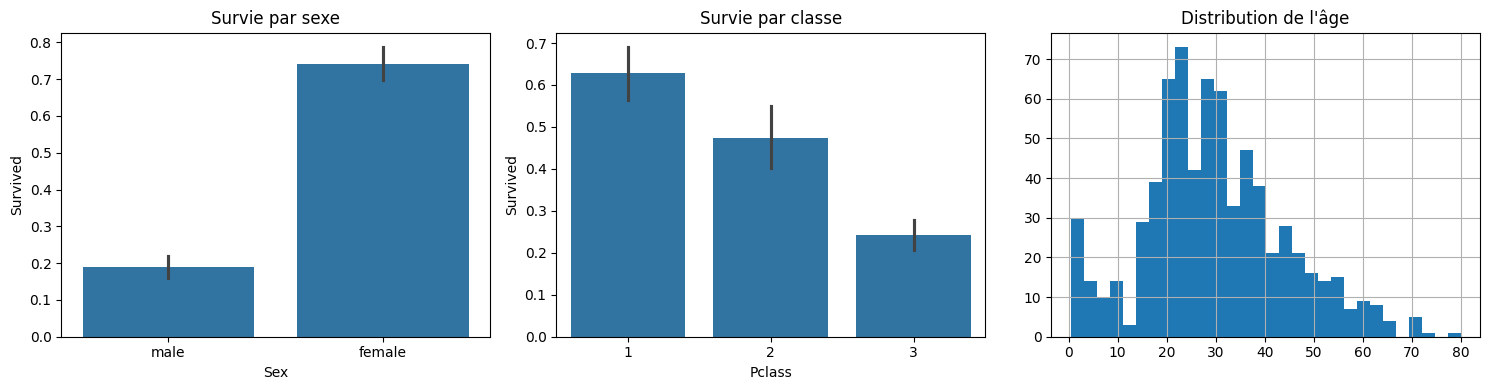

In [4]:
# Taux de survie global
print("Taux de survie :", round(train['Survived'].mean() * 100, 2), "%")

# Visualisations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Par sexe
sns.barplot(x='Sex', y='Survived', data=train, ax=axes[0])
axes[0].set_title('Survie par sexe')

# Par classe
sns.barplot(x='Pclass', y='Survived', data=train, ax=axes[1])
axes[1].set_title('Survie par classe')

# Par âge
train['Age'].hist(bins=30, ax=axes[2])
axes[2].set_title("Distribution de l'âge")

plt.tight_layout()
plt.show()

In [5]:
def preprocess(df):
    df = df.copy()
    
    # On supprime les colonnes inutiles
    df = df.drop(columns=['Cabin', 'Ticket', 'Name', 'PassengerId'])
    
    # On remplit les valeurs manquantes
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    
    # On encode les colonnes texte en nombres
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    
    return df

train_clean = preprocess(train)
test_clean = preprocess(test)

print(train_clean.head())
print("\nValeurs manquantes :\n", train_clean.isnull().sum())

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    0  22.0      1      0   7.2500         0
1         1       1    1  38.0      1      0  71.2833         1
2         1       3    1  26.0      0      0   7.9250         0
3         1       1    1  35.0      1      0  53.1000         0
4         0       3    0  35.0      0      0   8.0500         0

Valeurs manquantes :
 Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# On sépare les features (X) de la cible (y)
X = train_clean.drop(columns=['Survived'])
y = train_clean['Survived']

# On divise en set d'entraînement et set de validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# On crée et entraîne le modèle
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# On évalue
y_pred = model.predict(X_val)
print("Accuracy :", round(accuracy_score(y_val, y_pred) * 100, 2), "%")

Accuracy : 82.68 %


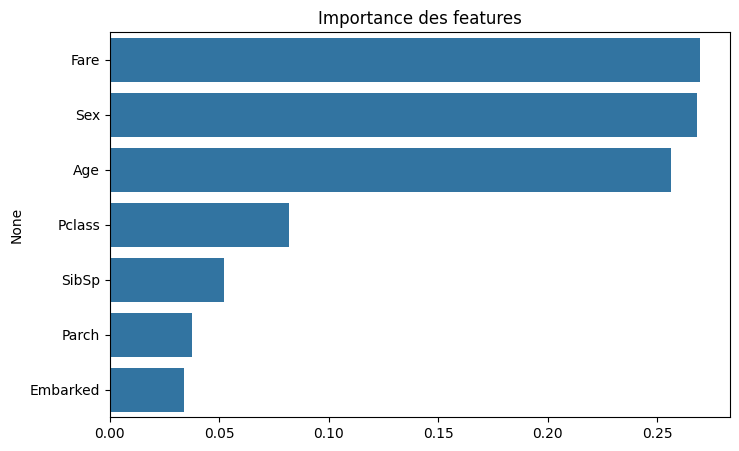

Fare        0.269744
Sex         0.268418
Age         0.256426
Pclass      0.081891
SibSp       0.052077
Parch       0.037390
Embarked    0.034054
dtype: float64


In [7]:
# Importance des features
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Importance des features")
plt.show()

print(importances)

In [8]:
# Prédictions sur le test set
predictions = model.predict(test_clean)

# Création du fichier de soumission
output = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': predictions
})

output.to_csv('submission.csv', index=False)
print("Fichier créé ! Aperçu :")
print(output.head(10))

Fichier créé ! Aperçu :
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         1
4          896         0
5          897         0
6          898         0
7          899         0
8          900         1
9          901         0
